UMAP on the same digits dataset as `21-pca/` and `22-tsne/`, completing the three-way comparison. UMAP is also non-linear like t-SNE, but built on manifold-learning theory and is typically much faster while preserving more global structure. Requires `pip install umap-learn` (already installed here).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import umap

digits = load_digits()
X, y = digits.data, digits.target
X_scaled = StandardScaler().fit_transform(X)
print("umap version:", umap.__version__)

umap version: 0.5.12


In [2]:
t0 = time.time()
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)
umap_time = time.time() - t0
print(f"UMAP took {umap_time:.1f}s for {X.shape[0]} points")

C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP took 8.4s for 1797 points


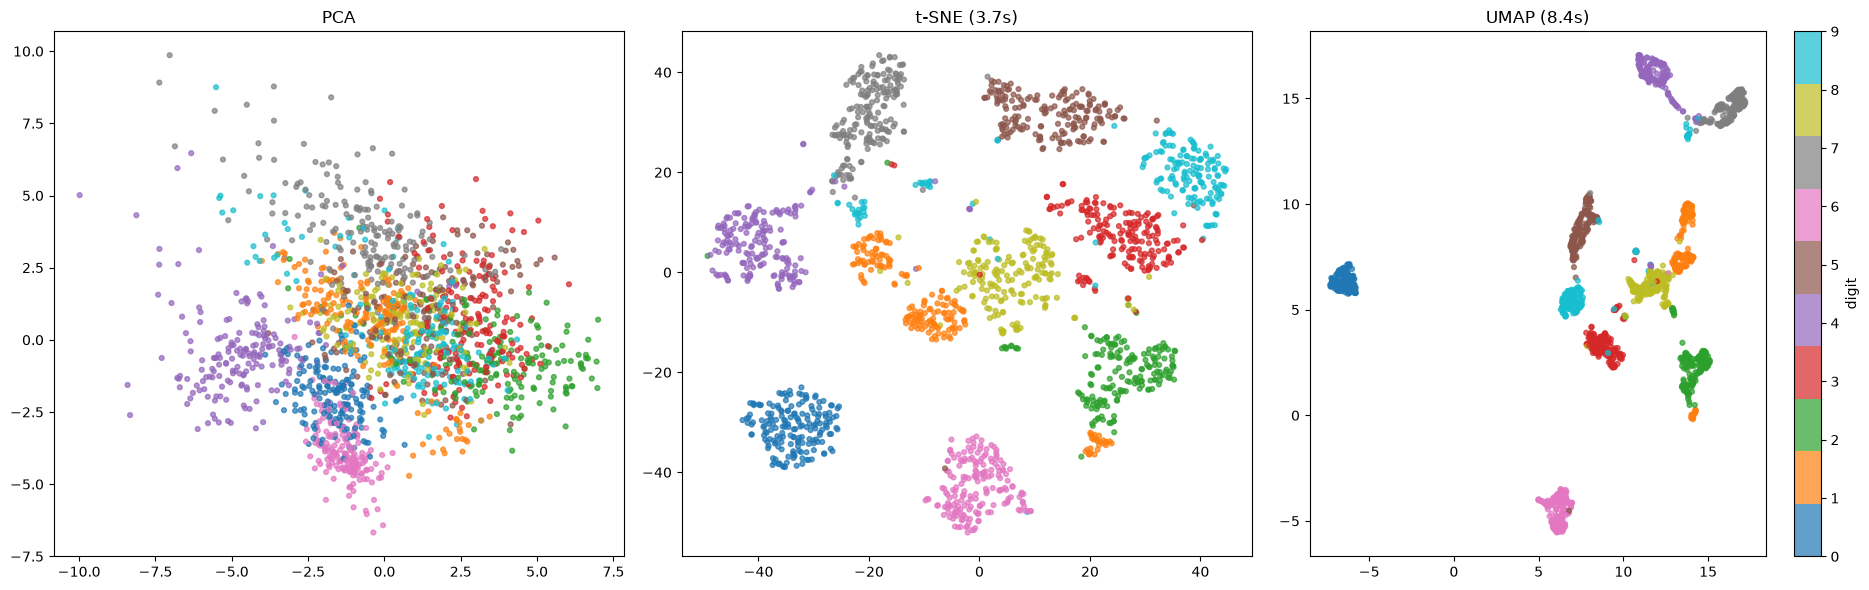

t-SNE time: 3.69s, UMAP time: 8.42s


In [3]:
# Recompute PCA and t-SNE for a fair 3-way side-by-side
X_pca = PCA(n_components=2).fit_transform(X_scaled)

t0 = time.time()
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca').fit_transform(X_scaled)
tsne_time = time.time() - t0

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=12, alpha=0.7)
axes[0].set_title('PCA')
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=12, alpha=0.7)
axes[1].set_title(f't-SNE ({tsne_time:.1f}s)')
sc = axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', s=12, alpha=0.7)
axes[2].set_title(f'UMAP ({umap_time:.1f}s)')
plt.colorbar(sc, ax=axes[2], label='digit')
plt.tight_layout()
plt.show()
print(f"t-SNE time: {tsne_time:.2f}s, UMAP time: {umap_time:.2f}s")

C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


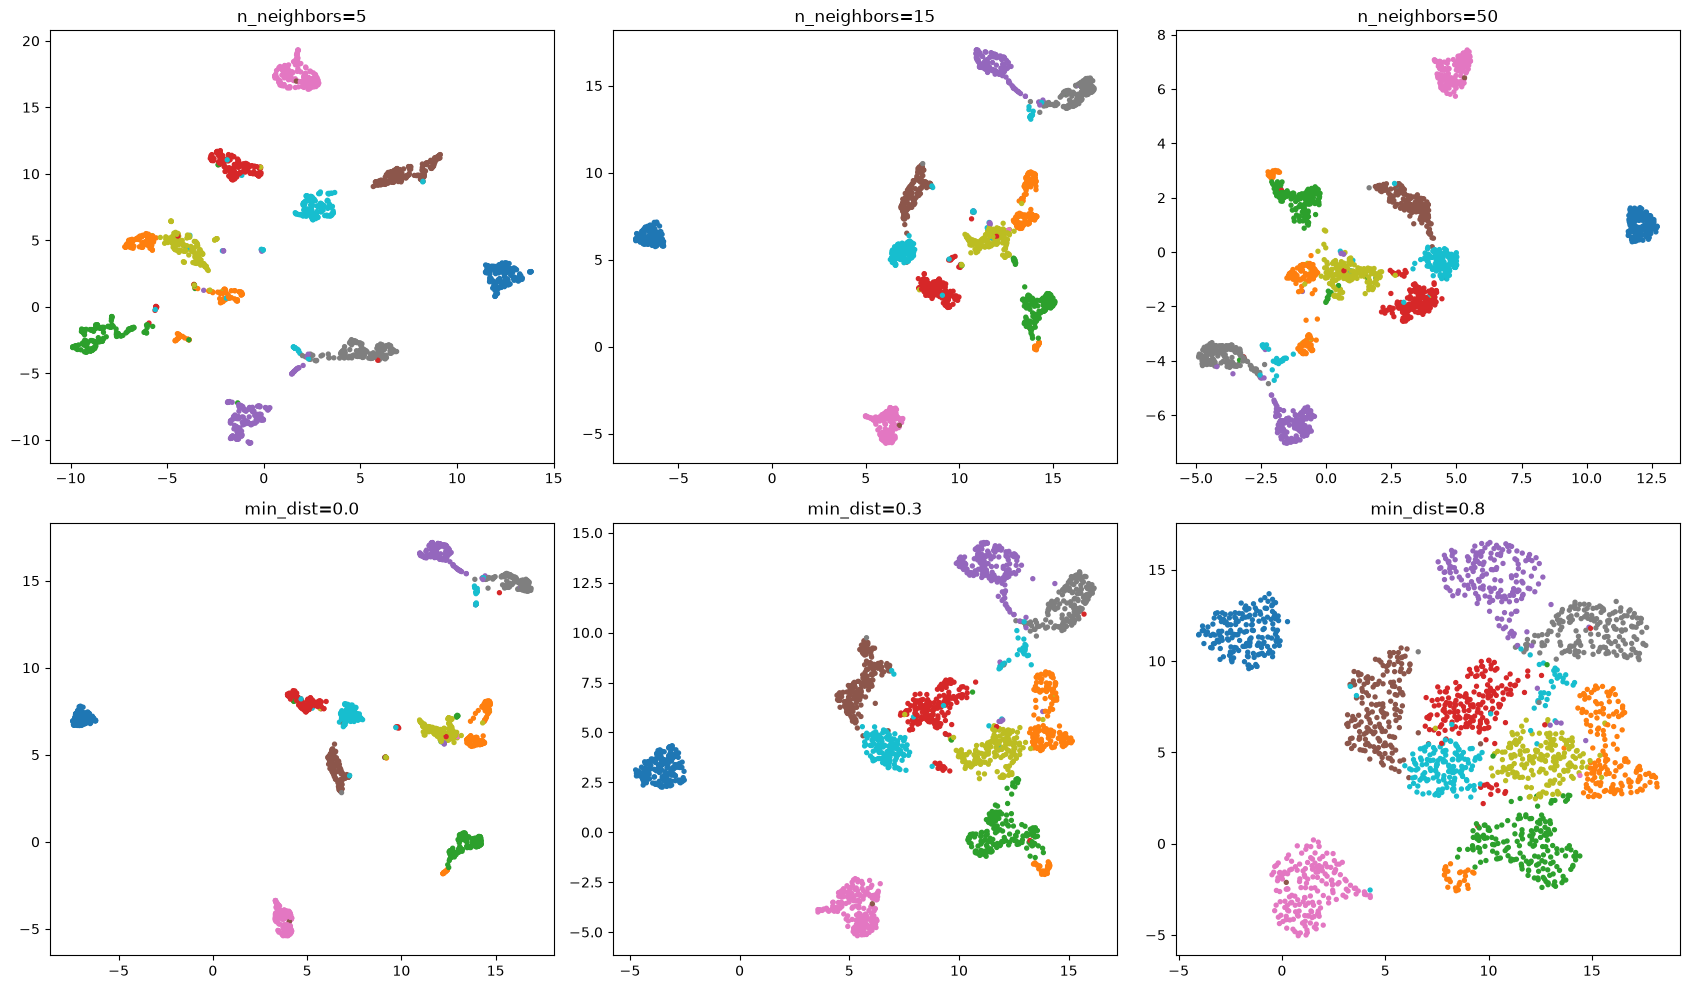

n_neighbors: small -> more local/fragmented structure, large -> more global structure preserved.
min_dist: small -> tightly packed clusters, large -> more even/spread-out point placement.


In [4]:
# n_neighbors and min_dist are UMAP's two key hyperparameters
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for ax, nn in zip(axes[0], [5, 15, 50]):
    r = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1, random_state=42)
    emb = r.fit_transform(X_scaled)
    ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap='tab10', s=8)
    ax.set_title(f'n_neighbors={nn}')

for ax, md in zip(axes[1], [0.0, 0.3, 0.8]):
    r = umap.UMAP(n_components=2, n_neighbors=15, min_dist=md, random_state=42)
    emb = r.fit_transform(X_scaled)
    ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap='tab10', s=8)
    ax.set_title(f'min_dist={md}')

plt.tight_layout()
plt.show()
print("n_neighbors: small -> more local/fragmented structure, large -> more global structure preserved.")
print("min_dist: small -> tightly packed clusters, large -> more even/spread-out point placement.")

In [5]:
print("Summary of the three dimensionality reduction methods on the same data:")
print(f"  PCA:   linear, deterministic, fast, preserves global variance, invertible (lossy reconstruction)")
print(f"  t-SNE: non-linear, stochastic, slow ({tsne_time:.1f}s), preserves local neighborhoods, not invertible")
print(f"  UMAP:  non-linear, stochastic, fast ({umap_time:.1f}s), preserves local AND more global structure than t-SNE, not invertible")

Summary of the three dimensionality reduction methods on the same data:
  PCA:   linear, deterministic, fast, preserves global variance, invertible (lossy reconstruction)
  t-SNE: non-linear, stochastic, slow (3.7s), preserves local neighborhoods, not invertible
  UMAP:  non-linear, stochastic, fast (8.4s), preserves local AND more global structure than t-SNE, not invertible
